# Spatially resolved topological flux

The real-space counterpart of the Berry curvature is a *local*, position-resolved marker
$\Gamma(\mathbf r)$ obtainable from ground-state projectors alone (a Bianco-Resta-type commutator of
position and projector operators), with no reference to a Brillouin zone
(`topology.real_space_chern`), whose average over a region $A$ deep in the bulk,
$C=\frac{1}{A}\int_A\Gamma(\mathbf r)\,d^2\mathbf r$, is the Chern number. Evaluated on a finite
Haldane-model island, the marker is quantized to the bulk value deep in the interior, with edge
sites carrying compensating opposite-sign flux that cancels the bulk contribution exactly (the
real-space imprint of the bulk-boundary correspondence). The island is spinful, the default of
`g.get_hamiltonian()`, so the bulk value is $C=2$ (two spin copies). The marker of each site is
divided by the area the site occupies, the area of its Voronoi cell, which in the honeycomb lattice
is half the area of the unit cell, and with $t_2=0.2$ the gap is large enough for the six innermost
sites to read $2.000$.

Marker of the six innermost sites: 2.0


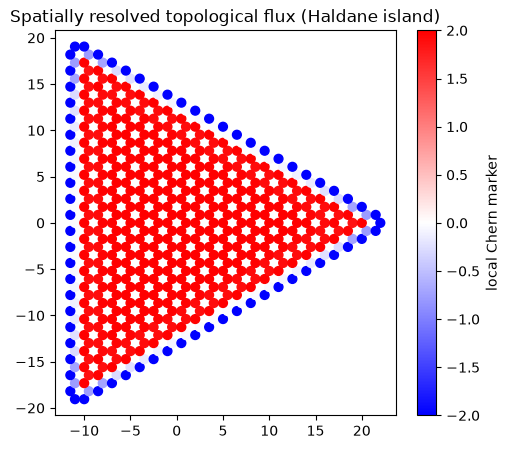

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import islands, topology

g = islands.get_geometry(name="honeycomb",n=8,nedges=3)
h = g.get_hamiltonian()
h.add_haldane(0.2)
(r,c) = topology.real_space_chern(h)
center = np.argsort(np.linalg.norm(r-r.mean(axis=0),axis=1))[:6] # six innermost sites
print("Marker of the six innermost sites:",np.round(np.mean(c[center]),3))

plt.figure(figsize=(5.5,5))
plt.scatter(r[:,0],r[:,1],c=c,cmap="bwr",vmin=-2.0,vmax=2.0,s=40)
plt.colorbar(label="local Chern marker")
plt.axis("equal")
plt.title("Spatially resolved topological flux (Haldane island)")
plt.show()

### Comparison with the literature
The marker is the local Chern number of Eq. (9) in Ref. [1], per site and divided by the area of
the site, $3\sqrt3/4$ for the honeycomb lattice with unit first-neighbor distance, and the map is
the two-dimensional version of the right panel of Fig. 3 in Ref. [1], a cut through a topological
Haldane-model flake where the marker is quantized in the bulk and negative at the boundary, and
sums to zero over the whole sample. The flake there is rectangular, spinless and carries a
sublattice potential, so its bulk value is 1 rather than the 2 of this spinful triangular island.

[1] R. Bianco and R. Resta, *Mapping topological order in coordinate space*, Phys. Rev. B **84**,
241106(R) (2011), [arXiv:1111.5697](https://arxiv.org/abs/1111.5697)